In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
class MOLR:
    def __init__(self,p,r):
        """
        p: prediction horizon
        r: memory of model (sample amount in asingle row of X)
        m: feature amount
        n: dataset length
        """
        self.p = p
        self.r = r
        self.n = None
        self.m = None
        self.W = None

    def _show(lst):
        for row in lst:
            print(row)

    def _gradient(self,Xt,Y):
        return (2 / (self.n-self.p-self.r+1)) * Xt.T @ (Xt @ self.W - Y)

    def _loss(self,Xt,Y):
        diff = Xt @ self.W - Y
        return (1 / (self.n-self.p-self.r+1)) * np.trace(diff.T @ diff)

    def _rel_cond(self,old_loss,loss,epsilon):
        return abs((loss-old_loss)/old_loss)>epsilon

    def fit(self,df,epsilon=0.01,alpha=0.01,inform=0):
        """
        epsilon: relative error threshold
        alpha: step size
        inform: 0(least informed),1,2,3(most informed)

        returns loss history
        """
        print("Model training started...")

        self.n, self.m = df.shape

        # create X
        X = np.array([df[k : k + self.r] for k in range(self.n - self.p - self.r + 1)])
        X = X.reshape(X.shape[0], -1)

        # create Y
        Y = np.array([df[k + self.r : k + self.r + self.p] for k in range(self.n - self.p - self.r + 1)])
        Y = Y.reshape(Y.shape[0], -1)

        # create Xt
        X_flattened = X.reshape(X.shape[0], -1)
        ones_column = np.ones((X_flattened.shape[0], 1))
        Xt = np.column_stack((ones_column, X_flattened))

        # create W
        self.W = np.zeros((self.r * self.m + 1, self.p * self.m))

        if inform==3:
            print("df shape:", df.shape)
            print("X shape:", X.shape)
            print("Y shape:", Y.shape)
            print("Xt shape:", Xt.shape)
            print("W shape:", self.W.shape)
            print("\n-- Weights First --")
            self._show(self.W)

        iter_num = 0
        loss = self._loss(Xt, Y)
        losses = [loss]

        while iter_num == 0 or self._rel_cond(old_loss, loss, epsilon):
            old_loss = loss
            self.W = self.W - alpha * self._gradient(Xt, Y)
            loss = self._loss(Xt, Y)

            if inform == 2:
                print(f"iter {iter_num}: loss: {loss}, old loss: {old_loss}")
            elif inform == 1:
                print(f"iter {iter_num}: loss: {loss}")

            iter_num += 1
            losses.append(loss)

        if inform == 3:
            print("\n-- Weights Last --")
            self._show(self.W)

        print("Model training finished.")
        return losses

    def predict(self, X):
        """x: 1, x1, x2, ... , xrm"""
        x = X[-self.r:].flatten()
        x = np.insert(x, 0, 1)
        preds = x @ self.W
        answers = preds.reshape(self.p, self.m)

        return answers

In [3]:
def generate_synthetic_ts(n, m):
    t = np.arange(n)
    synthetic_data = np.zeros((n, m))

    for col in range(m):
        trend_slope = np.random.uniform(-0.5, 0.5)
        seasonal_amplitude = np.random.uniform(5, 15)
        period = np.random.randint(10, 30)
        noise_level = np.random.uniform(1, 3)

        phase_shift = np.random.uniform(0, 2 * np.pi)

        trend = trend_slope * t
        seasonality = seasonal_amplitude * np.sin((2 * np.pi * t / period) + phase_shift)
        noise = np.random.normal(0, noise_level, n)

        f = trend + seasonality + noise

        synthetic_data[:, col] = f

    return synthetic_data

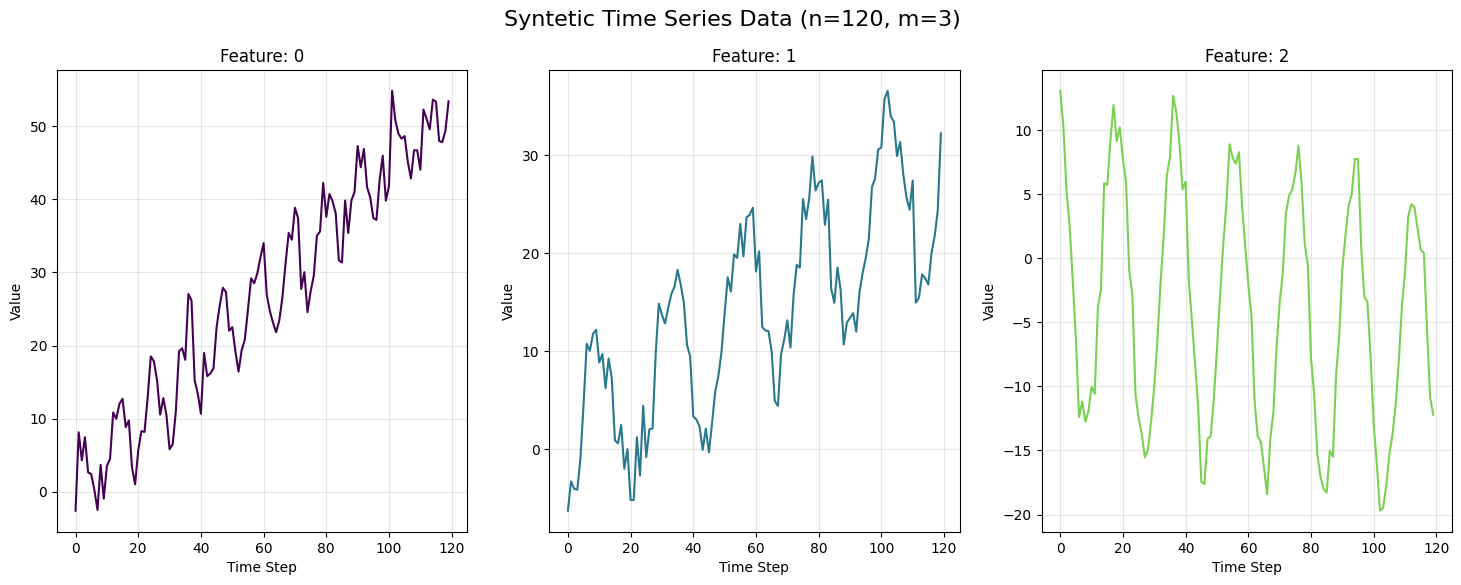

In [4]:
# adjust parameters
params = {
    "n":120, # dataset length
    "m":3, # feature amount
    "p":20, # prediction horizon
    "r":20 # memory
}

# create df
df = generate_synthetic_ts(n=params["n"], m=params["m"])

fig, axs = plt.subplots(1, 3, figsize=(6*params["m"], 6))
colors = plt.cm.viridis(np.linspace(0, 0.8, params["m"]))
for i, (ax, color) in enumerate(zip(axs, colors)):
    ax.plot(df[:,i], c=color)
    ax.set_title(f"Feature: {i}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Syntetic Time Series Data (n={params["n"]}, m={params["m"]})", fontsize=16)
plt.show()

In [5]:
df[:10]

array([[ -2.60349645,  -6.30686201,  13.04134412],
       [  8.12918971,  -3.30614717,  10.24599869],
       [  4.29422574,  -4.06873958,   5.21635617],
       [  7.45416156,  -4.16477923,   2.49990503],
       [  2.66336105,  -0.94625307,  -1.83743991],
       [  2.4070563 ,   4.54732715,  -6.33381406],
       [  0.26246845,  10.72559779, -12.40301752],
       [ -2.49295415,  10.01945587, -11.18397226],
       [  3.66948905,  11.73558442, -12.76961227],
       [ -0.95830406,  12.17675771, -11.93704761]])

In [6]:
scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(df)
scaled_df[:10]

array([[0.        , 0.        , 1.        ],
       [0.18671427, 0.0699805 , 0.91463649],
       [0.11999822, 0.05219587, 0.76104261],
       [0.17497095, 0.04995611, 0.67808835],
       [0.09162641, 0.12501625, 0.54563567],
       [0.08716753, 0.25313355, 0.4083266 ],
       [0.04985859, 0.39721872, 0.22298688],
       [0.00192308, 0.38075059, 0.26021376],
       [0.1091298 , 0.4207729 , 0.21179191],
       [0.02862106, 0.43106162, 0.23721655]])

In [7]:
# build model
model = MOLR(p=20,r=20)
losses = model.fit(scaled_df,inform=2,epsilon=0.005)

Model training started...
iter 0: loss: 11.788132511453723, old loss: 20.33597967733341
iter 1: loss: 7.304911404546428, old loss: 11.788132511453723
iter 2: loss: 4.940759709272323, old loss: 7.304911404546428
iter 3: loss: 3.681749714701531, old loss: 4.940759709272323
iter 4: loss: 2.9994610049292154, old loss: 3.681749714701531
iter 5: loss: 2.618489851772747, old loss: 2.9994610049292154
iter 6: loss: 2.39528968676825, old loss: 2.618489851772747
iter 7: loss: 2.2550303406514796, old loss: 2.39528968676825
iter 8: loss: 2.1586930215007945, old loss: 2.2550303406514796
iter 9: loss: 2.085922261726494, old loss: 2.1586930215007945
iter 10: loss: 2.0260894083514747, old loss: 2.085922261726494
iter 11: loss: 1.9736354546296881, old loss: 2.0260894083514747
iter 12: loss: 1.925643996272964, old loss: 1.9736354546296881
iter 13: loss: 1.880576389201003, old loss: 1.925643996272964
iter 14: loss: 1.83761257435018, old loss: 1.880576389201003
iter 15: loss: 1.7963075387103469, old loss: 

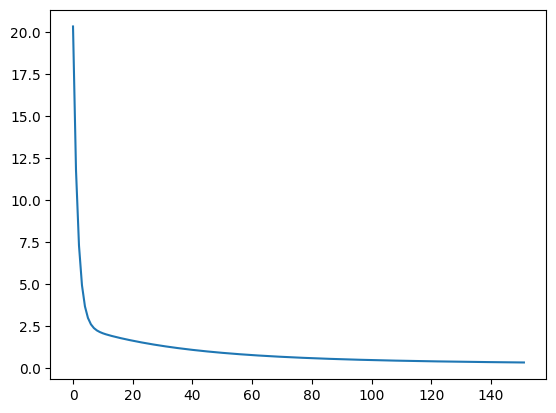

In [8]:
plt.plot(losses)

In [9]:
preds = model.predict(scaled_df)
preds_rescaled = scaler.inverse_transform(preds)
preds_rescaled

array([[ 4.94783210e+01,  2.55795889e+01, -1.34803496e+01],
       [ 5.07714460e+01,  2.70037922e+01, -1.52435893e+01],
       [ 5.18793326e+01,  2.85509972e+01, -1.61071377e+01],
       [ 5.27535107e+01,  3.02561576e+01, -1.60144184e+01],
       [ 5.36321532e+01,  3.15897940e+01, -1.46620143e+01],
       [ 5.46597909e+01,  3.27864398e+01, -1.26028899e+01],
       [ 5.52421356e+01,  3.36558124e+01, -9.97765214e+00],
       [ 5.53520052e+01,  3.41202334e+01, -7.09836069e+00],
       [ 5.54363969e+01,  3.40375687e+01, -4.35966469e+00],
       [ 5.55402523e+01,  3.39522606e+01, -1.89695859e+00],
       [ 5.53731922e+01,  3.42018302e+01, -5.90025549e-02],
       [ 5.56742992e+01,  3.30205346e+01,  1.10107694e+00],
       [ 5.58624650e+01,  3.16499017e+01,  1.22698467e+00],
       [ 5.61052153e+01,  3.04295604e+01,  3.51544172e-01],
       [ 5.71214656e+01,  2.92247279e+01, -1.50801178e+00],
       [ 5.80451315e+01,  2.80770713e+01, -3.93817247e+00],
       [ 5.83142007e+01,  2.74395245e+01

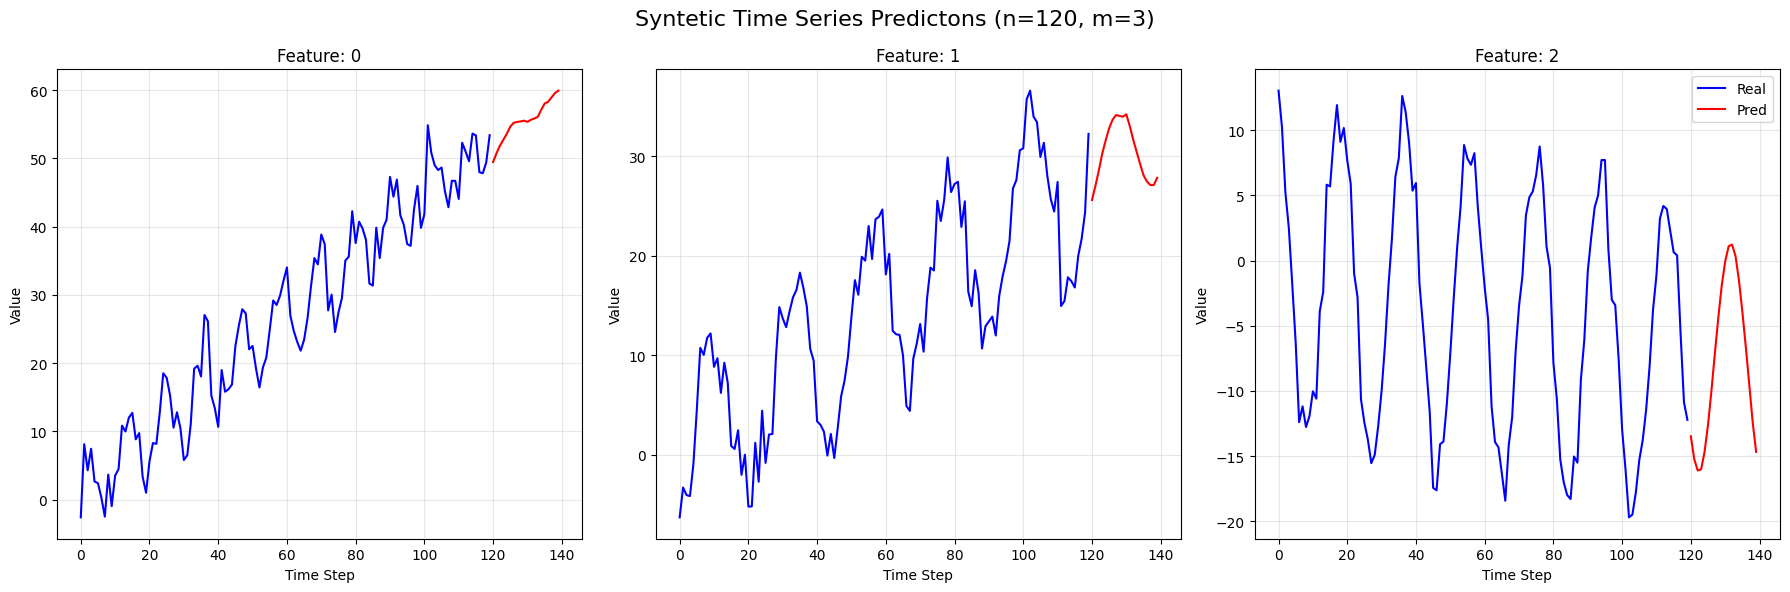

In [10]:
# plot predictions
fig, axs = plt.subplots(1, 3, figsize=(6*params["m"], 6))
for i, ax in enumerate(axs):
    ax.plot(df[:,i], c="blue", label="Real")
    preds_x_axis = range(len(df), len(df) + len(preds_rescaled))
    ax.plot(preds_x_axis, preds_rescaled[:,i], c="red", label="Pred")
    ax.set_title(f"Feature: {i}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Value")
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Syntetic Time Series Predictons (n={params["n"]}, m={params["m"]})", fontsize=16)
plt.tight_layout()
plt.legend()
plt.show()